![banner](../../../docs/figs/brand_identity/banner.png)

# Week 9: Fairness in Credit Decisions

## Lesson overview

Use German Credit data to demonstrate fairness checks across age groups and reweighing. The inputs are credit examples and labels; the outputs are group fairness measures and model results from two training approaches.

**By the end, you can:** identify the protected group and outcome label; compare group measures before and after adjustment; and inspect both fairness and predictive performance.

**Before you begin:** This uses German Credit data in the repository, so no download is needed. The lesson focuses on one reweighting method. Improved measures do not mean real-world bias has been removed, and they are not enough to make credit decisions.

<p align="center"><img src="../../../docs/figs/credit_teaching_flow.svg" alt="Credit audit workflow: age groups and outcomes, reweighed training rows, two models, and separate predictive and fairness results" width="100%"><br><em>Figure 1. The Starter Kit shows where reweighing acts and why prediction and group-gap measures are read separately.</em></p>

**Use the figure:** The weights change training, not the held-out labels. Compare the two models on the same test records and state the sign of each group difference before calling it an improvement.


## Tutorial focus and relationship to the Starter Kit

This short tutorial focuses on one fairness intervention: reweighing training examples by age group, then comparing group metrics and predictive performance. It uses the repository German Credit data under `data/german_credits/` via the course environment.

The [Credit Decision Starter Kit](../../../starter_kits/5_bias_detection_interpretability/credit_audit/credit_decision.ipynb) is the larger project workflow. Use this tutorial to understand the reweighing mechanism; use the Starter Kit for a fuller audit and decision context. Fairness metrics depend on the chosen protected attribute, label definition, and threshold.


# Bias in ML: case of credit decision

Machine learning models trained on historical data can unintentionally learn and amplify societal biases. In credit decision-making, for instance, a model may favor certain age groups if past data shows higher repayment rates among them — even if using age as a factor is legally or ethically problematic.

AI Fairness 360 (AIF360) is a toolkit that provides fairness metrics to detect such biases, and mitigation techniques to address them. By identifying protected attributes (e.g., age, race, gender), it enables developers to audit and improve the fairness of ML systems, ensuring both ethical integrity and regulatory compliance.

This tutorial demonstrates how to apply AIF360 to detect and mitigate age bias in credit decisions.

In [2]:
import numpy as np
import pandas as pd
np.random.seed(0)

from aif360.datasets import GermanDataset
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing

from IPython.display import Markdown, display

## Step 1: Load dataset, specifying protected attribute, and split dataset into train and test

Load the repository data, identify age groups and outcome labels, then split the examples into training and test sets. Later adjustments apply only to training data.

In [4]:
from ccai9012.paths import DATA_DIR
from ccai9012.credit_utils import load_german_credit_dataset
from sklearn.model_selection import train_test_split

# Load the repository copy and create reproducible train/test partitions.
dataset_orig = load_german_credit_dataset(DATA_DIR / "german_credits" / "german.data")
dataset_orig_train, dataset_orig_test = dataset_orig.split([0.7], shuffle=True)

# StandardDataset encodes the age threshold as 0 (under 25) / 1 (25 or older).
unprivileged_groups = [{"age": 0.0}]
privileged_groups = [{"age": 1.0}]


## Step 2: Compute fairness metric on original training dataset

Record group measures before adjustment as a baseline. The mean difference describes a difference in outcome rates; it does not explain the cause.

In [5]:
metric_orig_train = BinaryLabelDatasetMetric(dataset_orig_train, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
display(Markdown("#### Original training dataset"))
print("Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_orig_train.mean_difference())

#### Original training dataset

Difference in mean outcomes between unprivileged and privileged groups = -0.169905


## Step 3: Mitigate bias by transforming the original dataset

Reweighing assigns training weights to group-and-label combinations; it does not change the original labels.

In [6]:
# Calculate sample weights to balance group-and-outcome combinations.
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
# Apply the calculated weights to training data only.
dataset_transf_train = RW.fit_transform(dataset_orig_train)

## Step 4: Compute fairness metric on transformed dataset

Use the same measure to check the reweighted training data so the comparison is consistent. A value near zero means only that this particular rate difference is smaller.

In [7]:
metric_transf_train = BinaryLabelDatasetMetric(dataset_transf_train, 
                                               unprivileged_groups=unprivileged_groups,
                                               privileged_groups=privileged_groups)
display(Markdown("#### Transformed training dataset"))
print("Difference in mean outcomes between unprivileged and privileged groups = %f" % metric_transf_train.mean_difference())

#### Transformed training dataset

Difference in mean outcomes between unprivileged and privileged groups = 0.000000


## Step 5: How is the data transformed?

Inspect the sample weights to see how the method changes the importance of each row during training.

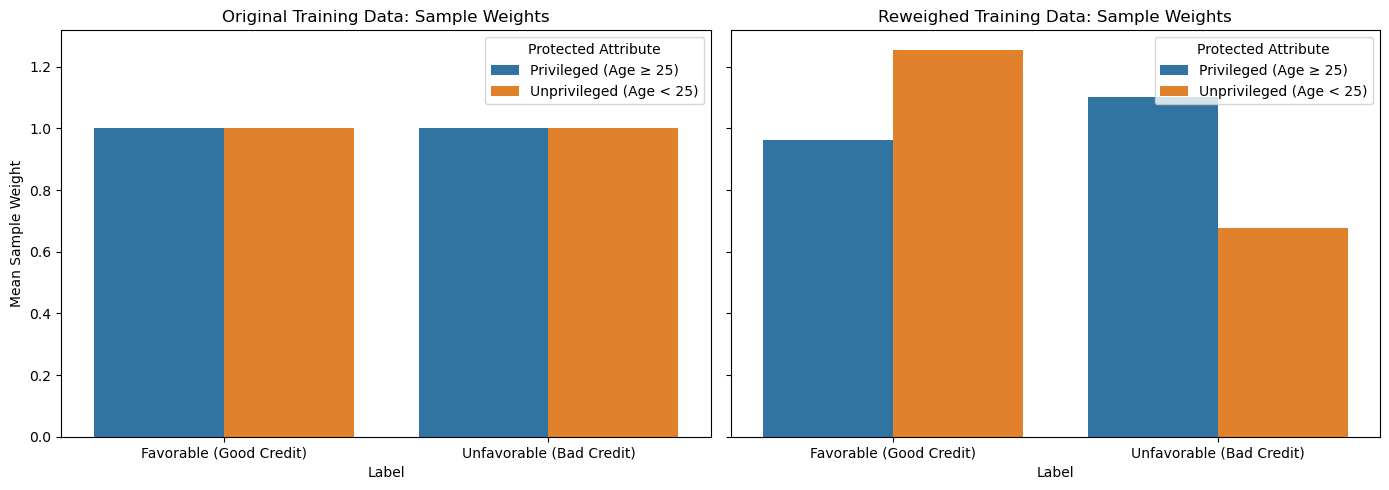

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Extract protected attribute, label, and weights from a BinaryLabelDataset
def extract_weights(dataset):
    # If instance_weights do not exist (e.g., original data), assume weight = 1 for all
    weights = dataset.instance_weights if hasattr(dataset, 'instance_weights') else np.ones(len(dataset.labels))
    df = pd.DataFrame({
        'protected': dataset.protected_attributes[:, 0],  # e.g., age binary attribute
        'label': dataset.labels[:, 0],                    # class label
        'weight': weights
    })
    return df

# Extract data for original and reweighted datasets
df_orig = extract_weights(dataset_orig_train)
df_rw = extract_weights(dataset_transf_train)

protected_mapping = {
    0: "Unprivileged (Age < 25)",
    1: "Privileged (Age ≥ 25)"
}
label_mapping = {
    2: "Unfavorable (Bad Credit)",
    1: "Favorable (Good Credit)"
}

df_orig['protected_str'] = df_orig['protected'].map(protected_mapping)
df_orig['label_str'] = df_orig['label'].map(label_mapping)

df_rw['protected_str'] = df_rw['protected'].map(protected_mapping)
df_rw['label_str'] = df_rw['label'].map(label_mapping)

# Compute mean weights per (protected_str, label_str) group
grouped_orig = df_orig.groupby(['protected_str', 'label_str'])['weight'].mean().reset_index()
grouped_rw = df_rw.groupby(['protected_str', 'label_str'])['weight'].mean().reset_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.barplot(data=grouped_orig, x='label_str', y='weight', hue='protected_str', ax=axes[0])
axes[0].set_title('Original Training Data: Sample Weights')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Mean Sample Weight')
axes[0].legend(title='Protected Attribute')

sns.barplot(data=grouped_rw, x='label_str', y='weight', hue='protected_str', ax=axes[1])
axes[1].set_title('Reweighed Training Data: Sample Weights')
axes[1].set_xlabel('Label')
axes[1].legend(title='Protected Attribute')

plt.tight_layout()
plt.show()

In [9]:
print("Original grouped weights:")
print(grouped_orig)

print("\nReweighted grouped weights:")
print(grouped_rw)

Original grouped weights:
             protected_str                 label_str  weight
0    Privileged (Age ≥ 25)   Favorable (Good Credit)     1.0
1    Privileged (Age ≥ 25)  Unfavorable (Bad Credit)     1.0
2  Unprivileged (Age < 25)   Favorable (Good Credit)     1.0
3  Unprivileged (Age < 25)  Unfavorable (Bad Credit)     1.0

Reweighted grouped weights:
             protected_str                 label_str    weight
0    Privileged (Age ≥ 25)   Favorable (Good Credit)  0.962295
1    Privileged (Age ≥ 25)  Unfavorable (Bad Credit)  1.100625
2  Unprivileged (Age < 25)   Favorable (Good Credit)  1.255556
3  Unprivileged (Age < 25)  Unfavorable (Bad Credit)  0.678000


## Step 6: Train 2 models with original and transformed datasets

Train one model on the original data and one on the reweighted data. Compare them on the same test set rather than treating training results as test results.

In [10]:
from lightgbm import LGBMClassifier
from aif360.metrics import ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from sklearn.metrics import accuracy_score, roc_auc_score
from copy import deepcopy

In [11]:
# Helper function to extract features (X), labels (y), and sample weights (w) from a BinaryLabelDataset
def dataset_to_X_y_w(dataset: BinaryLabelDataset):
    X = dataset.features                    # feature matrix (numpy array)
    y = dataset.labels.ravel()              # labels as 1D array
    # if instance weights exist (e.g., after reweighing), use them; otherwise assume all weights = 1
    w = dataset.instance_weights if hasattr(dataset, 'instance_weights') else np.ones(len(y))
    return X, y, w

In [12]:
# Convert to X,y,w for original training data
X_train_orig, y_train_orig, w_train_orig = dataset_to_X_y_w(dataset_orig_train)

# Convert to X,y,w for reweighed training data
X_train_rw, y_train_rw, w_train_rw = dataset_to_X_y_w(dataset_transf_train)

# Convert to X,y,w for test data
X_test, y_test, w_test = dataset_to_X_y_w(dataset_orig_test)

In [11]:
# Train model on original training data
model_orig = LGBMClassifier(random_state=42)
model_orig.fit(X_train_orig, y_train_orig, sample_weight=w_train_orig)
y_pred_orig = model_orig.predict(X_test)
y_prob_orig = model_orig.predict_proba(X_test)[:, 1]

# Train model on reweighed training data
model_rw = LGBMClassifier(random_state=42)
model_rw.fit(X_train_rw, y_train_rw, sample_weight=w_train_rw)
y_pred_rw = model_rw.predict(X_test)
y_prob_rw = model_rw.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 210, number of negative: 490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/opt/anaconda3/envs/ccai9012/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ccai9012/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ccai9012/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ccai9012/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Evaluate model performances on test set

Review predictive performance and fairness measures together. There may be trade-offs, and this example is not enough to set a real credit policy.

In [12]:
# Prepare predicted label datasets for fairness metric calculation
dataset_orig_test_pred_orig = deepcopy(dataset_orig_test)
dataset_orig_test_pred_orig.labels = y_pred_orig.reshape(-1, 1)

dataset_orig_test_pred_rw = deepcopy(dataset_orig_test)
dataset_orig_test_pred_rw.labels = y_pred_rw.reshape(-1, 1)

In [13]:
# Calculate accuracy and AUC
acc_orig = accuracy_score(y_test, y_pred_orig)
auc_orig = roc_auc_score(y_test, y_prob_orig)

acc_rw = accuracy_score(y_test, y_pred_rw)
auc_rw = roc_auc_score(y_test, y_prob_rw)

# Calculate fairness metrics
metric_orig = ClassificationMetric(dataset_orig_test, dataset_orig_test_pred_orig,
                                   unprivileged_groups=unprivileged_groups,
                                   privileged_groups=privileged_groups)
metric_rw = ClassificationMetric(dataset_orig_test, dataset_orig_test_pred_rw,
                                unprivileged_groups=unprivileged_groups,
                                privileged_groups=privileged_groups)

print("Original Data Model Performance:")
print(f"  Accuracy: {acc_orig:.4f}")
print(f"  AUC: {auc_orig:.4f}")
print(f"  Statistical Parity Difference: {metric_orig.statistical_parity_difference():.4f}")
print(f"  Equal Opportunity Difference: {metric_orig.equal_opportunity_difference():.4f}")

print("\nReweighed Data Model Performance:")
print(f"  Accuracy: {acc_rw:.4f}")
print(f"  AUC: {auc_rw:.4f}")
print(f"  Statistical Parity Difference: {metric_rw.statistical_parity_difference():.4f}")
print(f"  Equal Opportunity Difference: {metric_rw.equal_opportunity_difference():.4f}")

Original Data Model Performance:
  Accuracy: 0.7833
  AUC: 0.7981
  Statistical Parity Difference: -0.1427
  Equal Opportunity Difference: -0.2173

Reweighed Data Model Performance:
  Accuracy: 0.7867
  AUC: 0.8000
  Statistical Parity Difference: -0.0354
  Equal Opportunity Difference: -0.0973


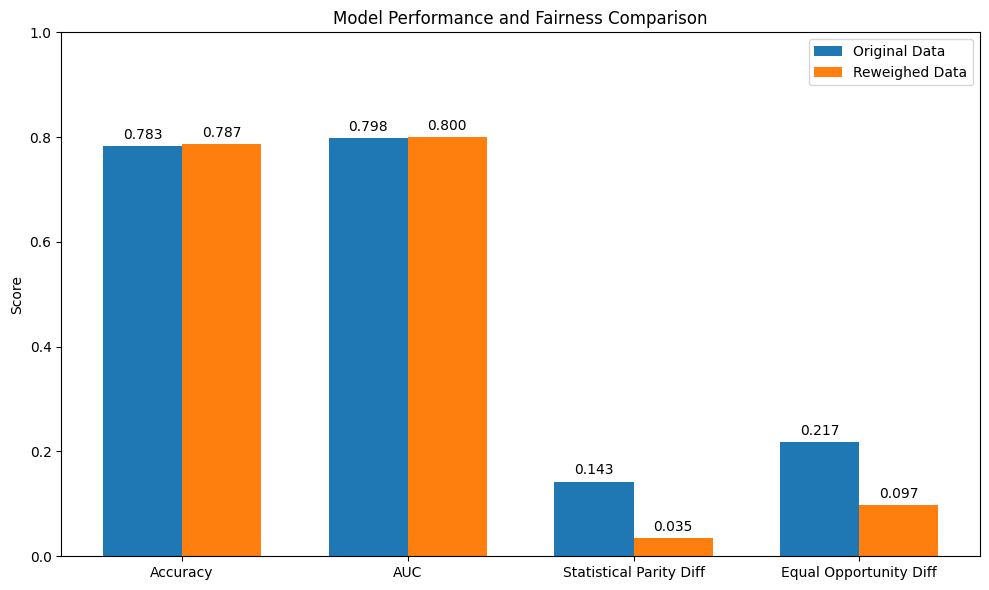

In [14]:
# Annotate bars with values
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


# Prepare metric names and corresponding values from your variables
metrics = ['Accuracy', 'AUC', 'Statistical Parity Diff', 'Equal Opportunity Diff']

orig_scores = [
    acc_orig,
    auc_orig,
    abs(metric_orig.statistical_parity_difference()),
    abs(metric_orig.equal_opportunity_difference())
]

rw_scores = [
    acc_rw,
    auc_rw,
    abs(metric_rw.statistical_parity_difference()),
    abs(metric_rw.equal_opportunity_difference())
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for original and reweighed models side-by-side
rects1 = ax.bar(x - width/2, orig_scores, width, label='Original Data')
rects2 = ax.bar(x + width/2, rw_scores, width, label='Reweighed Data')

# Labels and title
ax.set_ylabel('Score')
ax.set_title('Model Performance and Fairness Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

autolabel(rects1)
autolabel(rects2)

# Set y-limit to [0, 1] for clarity
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## What to take away

Reweighting changes how much each example matters during training. **Try next:** Check other groups and measures. **Limit:** One dataset and one measure cannot prove that a decision is fair.